# Neural Network + Clustering: An Alternative to Common Methods?

The first step is to scale down the dataset. We do this because we want to make features comparable so the model doesn't get biased by magnitude differences. For example, we have values (like sbytes) that are in the millions, whereas duration is in a few seconds. For k-means clustering (without scaling) the model will think that sbytes is wayyyy more important than duration, which may or may not be true. Distance calculations (like in k means etc) are dominated by large numbers...

So we need to scale to ensure each feature contributes fairly to learning

Steps to take:

1. Split features
   - numerical
   - categorical

2. Numerical pipeline:
   - log transform (if skewed)
   - StandardScaler

3. Categorical pipeline:
   - OneHotEncoder
   - (NO scaling)

4. Combine features

5. Feed into neural network

6. Extract learned features

7. Run k-means

Each notebook runs its own kernel so no variable declarations here will mess up declarations in the main file. Later on when I put this all back into the main file, we will need to remove the import stuff since it is already in the main file

## Splitting Features, Scaling / Encoding

In [2]:
import kagglehub
#this is the UNSW_NB15 dataset which is more modern
path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Owner\.cache\kagglehub\datasets\mrwellsdavid\unsw-nb15\versions\1


In [3]:
#inspect files
import os
os.listdir(path)
#we see all of the fils that we could've downloaded on kaggle

['NUSW-NB15_features.csv',
 'UNSW-NB15_1.csv',
 'UNSW-NB15_2.csv',
 'UNSW-NB15_3.csv',
 'UNSW-NB15_4.csv',
 'UNSW-NB15_LIST_EVENTS.csv',
 'UNSW_NB15_testing-set.csv',
 'UNSW_NB15_training-set.csv']

In [4]:
#but we really only want the training and testing set
import pandas as pd
train_df = pd.read_csv(os.path.join(path, "UNSW_NB15_training-set.csv"))
test_df = pd.read_csv(os.path.join(path, "UNSW_NB15_testing-set.csv"))

#for OUR project we want to combine both of these because more data = better feature learning, and clustering benefits from more samples

df_og = pd.concat([train_df, test_df], axis = 0)

In [5]:
#we need to split our data into categorical and numerical. We will apply one hot encoding on the categorical, and then we will scale the numerical features.
#note that WE ARE NOT scaling the categorical features. This would ruin their semantic meaning.
#we scale the numerical features because they differ vastly in scale... which is bad

#remember that we are using labels so we can use df_og.copy() to create a dataframe of categorical and a dataframe of numerical

df_cat = df_og[['proto', 'service', 'state']].copy() #we want to make a copy of the og datafram with only the categorical features in columns 1,2,3
df_num = df_og.drop(columns=['proto', 'service', 'state', 'id', 'attack_cat']).copy() #make a copy of the og dataframe with everything except the categorical features.

# #THIS IS ONE HOT ENCODING FOR CATEGORICAL FEATURES:
print("STARTING WITH ONE-HOT ENCODING FOR CATEGORICAL FEATURES...")

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(sparse_output=False)
# Requires a 2D array, so we use double brackets
encoded_array = encoder.fit_transform(df_cat) #these are our three categorical features that we need to encode

# Convert back to DataFrame with original names
encoded_df_cat = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out())

#THIS IS SCALING FOR NUMERICAL FEATURES:
#we want to use log transformation to reduce the influence of skewed features and outliers. then we can use standardization to scale the features to have a mean of 0 and a standard deviation of 1.
print("MOVING ON TO SCALING NUMERICAL FEATURES...")

from sklearn.preprocessing import FunctionTransformer
import numpy as np
transformer = FunctionTransformer(np.log1p) #log1p is used to handle zero values in the data, as log(0) is undefined. It computes log(1 + x), which allows us to apply the log transformation without encountering issues with zero values.
df_num_transformed = transformer.transform(df_num) #this applies the log transformation to all the numerical features in our df_num dataframe.

#now we need to take the log transformed data and standardize it using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df_num_transformed = scaler.fit_transform(df_num_transformed) #this standardizes the log transformed data to have a mean of 0 and a standard deviation of 1.




STARTING WITH ONE-HOT ENCODING FOR CATEGORICAL FEATURES...
MOVING ON TO SCALING NUMERICAL FEATURES...


In [6]:
#check if we have one hot encoded correctly
print(encoded_df_cat.shape)
print(df_cat.nunique())

#based on the output, we now have 157 columns. This indicated we've done it correctly because the og data has 133 unique proto, 13 unique service, and 11 unique state. 
#so each unique value in our df_cat became it's own one-hot column!

#check if we have scaled correctly
print(scaled_df_num_transformed.shape)
print(scaled_df_num_transformed.mean(axis=0)) #should be close to 0 because we standardized the data to have a mean of 0
print(scaled_df_num_transformed.std(axis=0)) #should be close to 1


# the output indicates that we have successfully scaled our numerical features to have a mean of 0 and a standard deviation of 1, which is what we wanted to achieve with standardization.

(257673, 157)
proto      133
service     13
state       11
dtype: int64
(257673, 40)
[ 1.76482344e-17 -1.97660226e-16 -5.64743502e-17  5.64743502e-17
 -1.12948700e-16  9.88301128e-17 -7.34166552e-16 -1.12948700e-16
  0.00000000e+00  1.97660226e-16  8.47115252e-17 -5.64743502e-17
 -3.52964688e-17 -1.34126582e-16  2.04719519e-16 -2.11778813e-17
 -4.23557626e-17  1.97660226e-16 -2.11778813e-16 -1.69423050e-16
 -7.05929377e-18 -7.05929377e-18  1.41185875e-17 -4.07674215e-16
 -8.47115252e-17  1.94130579e-17  4.94150564e-17  3.84731510e-16
  1.69423050e-16  3.10608926e-16  2.82371751e-17  5.64743502e-17
  4.23557626e-17  8.73587604e-17  1.50009993e-17  2.82371751e-17
 -8.47115252e-17  1.48245169e-16 -1.76482344e-17  1.69423050e-16]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Combining Features (to feed into Neural Network)

so now that we have our two separate (approrpiately scaled / encoded) dataframes. We can combine them to feed them to the neural network.

In [7]:
scaled_encoded_combined = np.hstack([encoded_df_cat, scaled_df_num_transformed]) 
#this combines the one hot encoded categorical features and the scaled numerical features into one array that we can use for our neural network. 
#we use hstack to stack them horizontally, meaning we are adding columns to our dataset. The one hot encoded features will be on the left and the scaled numerical features will be on the right. 
#this way we preserve row alignment.

print(scaled_encoded_combined.shape) #this should have the same number of rows as our original dataframe and the number of columns should be the sum of the one hot encoded columns and the scaled numerical columns.

(257673, 197)


the output indicates we have succesfully combined the two. we have the same number of rows as outputted above, and the colums is 197 = 157+40 which is also outputted above

## Neural Network (using combined dataframes)

the combined dataframe is called scaled_encoded_combined

We are going to take a base model and edit it to fit our needs. We will use pyTorch "Feedforward Neural Network" because our dataset is tabular, mixed, not sequential and not spatial. This is the standard model for these types of datasets.

In [9]:
%pip install torch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


we want to use a neural network to learn a lower-dimensional representation of the data that captures important behavioral patterns. This allows clustering to operate on a more structured feature space.”

Feedforward Neural Networks (FNN) are effective for feature selection. This is what we want to do, so we will use FFN as seen below 

In [10]:
import torch
import torch.nn as nn

# Define the network architecture
class FeedForwardNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(FeedForwardNN, self).__init__()

        #this is the encoder which is in charge of learning a compressed representation of our data. It takes in the input size, which is the number of features we have in our dataset, and outputs a compressed representation of our data that we can use for classification.

        self.encoder = nn.Sequential(nn.Linear(input_size, 128), #this is the first layer of our encoder, it takes in the input size and outputs 128 features
                                     nn.ReLU(), #this is the activation function for the first layer, it introduces non-linearity to the model which allows it to learn more complex patterns in the data

                                     nn.Linear(128,64), #then the second layer of our encoder takes in the 128 features from the first layer and outputs 64 features
                                     nn.ReLU(), #then we apply another activation function to introduce more non-linearity.

                                     nn.Linear(64,32), #this is the bottleneck layer of our encoder, it takes in the 64 features from the second layer and outputs 32 features. This is where we are learning a compressed representation of our data.
                                     nn.ReLU(),
        ) #finally we apply another activation function to the bottleneck layer to introduce more non-linearity.
                                     
        #this is the classifier, which is in charge of classifying our data based on the compressed representation learned by the encoder

        self.classifier = nn.Sequential(nn.Linear(32,64), #this is the first layer of our classifier, it takes in the 32 features from the bottleneck layer and outputs 64 features
                                        nn.ReLU(), #this is the activation function for the first layer of our classifier, it introduces non-linearity to the model which allows it to learn more complex patterns in the data
    
                                        nn.Linear(64,num_classes) #then the second layer of our classifier takes in the 64 features from the first layer and outputs num_classes features, which is the number of classes we have in our dataset. This is where we are learning to classify our data based on the compressed representation learned by the encoder.

        )
    
    def forward(self, x):
        features = self.encoder(x) #first we pass our input through the encoder to get the compressed representation of our data
        out = self.classifier(features) #then we pass the compressed representation through the classifier to get our final output
        return out
    
    def extract_features(self, x):
        return self.encoder(x) #this is a helper function that allows us to extract the compressed features from the encoder, which we can use for clustering later on.

X_tensor = torch.tensor(scaled_encoded_combined, dtype=torch.float32)

# Initialize model
input_size = scaled_encoded_combined.shape[1] #this is the number of features we have in our dataset after one hot encoding and scaling
num_classes = len(df_og['attack_cat'].unique()) #this is the number of unique classes we have in our target variable, which is the attack category
model = FeedForwardNN(input_size, num_classes)
outputs = model(X_tensor)



In [11]:
print("MODEL OUTPUTS:")
print(outputs)

print("PREDICTED CLASSES:")
predicted_classes = torch.argmax(outputs, dim=1)
print(predicted_classes)

probabilities = torch.softmax(outputs, dim=1)
print("PROBABILITIES:")
print(probabilities)

MODEL OUTPUTS:
tensor([[-0.0401,  0.1283, -0.0026,  ..., -0.0384,  0.0237, -0.0625],
        [-0.0427,  0.1269, -0.0020,  ..., -0.0374,  0.0229, -0.0623],
        [-0.0422,  0.1278, -0.0022,  ..., -0.0384,  0.0234, -0.0626],
        ...,
        [-0.0431,  0.1343, -0.0074,  ..., -0.0382,  0.0225, -0.0632],
        [-0.0377,  0.1352,  0.0016,  ..., -0.0341,  0.0213, -0.0598],
        [-0.0379,  0.1351,  0.0012,  ..., -0.0342,  0.0216, -0.0597]],
       grad_fn=<AddmmBackward0>)
PREDICTED CLASSES:
tensor([1, 1, 1,  ..., 1, 1, 1])
PROBABILITIES:
tensor([[0.0961, 0.1138, 0.0998,  ..., 0.0963, 0.1025, 0.0940],
        [0.0959, 0.1137, 0.0999,  ..., 0.0964, 0.1024, 0.0941],
        [0.0960, 0.1137, 0.0999,  ..., 0.0963, 0.1025, 0.0940],
        ...,
        [0.0958, 0.1144, 0.0993,  ..., 0.0963, 0.1023, 0.0939],
        [0.0961, 0.1142, 0.0999,  ..., 0.0964, 0.1019, 0.0940],
        [0.0961, 0.1142, 0.0999,  ..., 0.0964, 0.1019, 0.0940]],
       grad_fn=<SoftmaxBackward0>)


BUT! Notice that the predicted classes are all the same , and the probabilities are essentially the same as well. This is because we have only ran our model once and we are not training it. 

## Training the Model

In [ ]:
#this is the target variable that we want to predict, which is the attack category. We need to convert it to a tensor so we can use it for training our model.
y_encoded = df_og['attack_cat'].astype('category').cat.codes
y_tensor = torch.tensor(y_encoded.values, dtype=torch.long)

In [ ]:
from sklearn.model_selection import train_test_split

#this is where we split our data into a training set and a testing set. We want to use the training set to train our model and the testing set to evaluate our model's performance. We use stratify=y to ensure that the distribution of classes in the train and test sets is similar to the distribution in the original dataset. This is important for classification tasks to prevent bias in the model training and evaluation. By setting stratify=y, we ensure that the proportion of each class in the target variable y is maintained in both the training and testing sets.
X= scaled_encoded_combined
y= y_encoded.values #this is our target variable, which is the attack category. We want to predict this based on the features in X.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #stratify is used to ensure that the distribution of classes in the train and test sets is similar to the distribution in the original dataset. This is important for classification tasks to prevent bias in the model training and evaluation. By setting stratify=y, we ensure that the proportion of each class in the target variable y is maintained in both the training and testing sets.

In [26]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
) #this creates a dataset object that combines our input features (X_tensor) and our target labels (y_tensor) into a single object that we can use for training our neural network. We convert X_train to a tensor of type float32 and y_train to a tensor of type long, which is the appropriate data type for our target labels in a classification task.
loader = DataLoader(dataset, batch_size=64, shuffle=True) #this creates a dataloader object that allows us to iterate through our dataset in batches of 64 and shuffle the data at each epoch to improve training.

In [27]:
#now we have our model outputs and our target labels, we can calculate the loss and optimize our model using backpropagation. 
#we will use cross-entropy loss for multi-class classification and Adam optimizer for optimization.

criterion = nn.CrossEntropyLoss() #this is the loss function. it measures how well the predictions match true labels
optimizer = torch.optim.Adam(model.parameters(), lr=0.005) #creates optimizer (adam) which updates the model's weights to min loss

num_epochs = 30 #this is the number of times the model will see the entire dataset during training

for epoch in range(num_epochs): #for as many epochs as we have
    total_loss = 0
    
    for batch_X, batch_y in loader: #for each batch of data in our dataloader
        outputs = model(batch_X) #run the data through the model to get predictions
        loss = criterion(outputs, batch_y) #calculate how far off predictions are from true labels
        
        optimizer.zero_grad() #clears old gradient (the one from last step)
        loss.backward() #computes gradient of loss with respect to model parameters (weights)
        optimizer.step()#updates the model parameters using gradient
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}") #shows the loss for each epoch

Epoch 1, Loss: 0.3406
Epoch 2, Loss: 0.3257
Epoch 3, Loss: 0.3279
Epoch 4, Loss: 0.3259
Epoch 5, Loss: 0.3287
Epoch 6, Loss: 0.3560
Epoch 7, Loss: 0.3288
Epoch 8, Loss: 0.3531
Epoch 9, Loss: 0.3290
Epoch 10, Loss: 0.3260
Epoch 11, Loss: 0.3295
Epoch 12, Loss: 0.3249
Epoch 13, Loss: 0.3318
Epoch 14, Loss: 0.3267
Epoch 15, Loss: 0.3299
Epoch 16, Loss: 0.3313
Epoch 17, Loss: 0.3392
Epoch 18, Loss: 0.3281
Epoch 19, Loss: 0.3245
Epoch 20, Loss: 0.3252
Epoch 21, Loss: 0.3260
Epoch 22, Loss: 0.3253
Epoch 23, Loss: 0.3268
Epoch 24, Loss: 0.3368
Epoch 25, Loss: 0.3310
Epoch 26, Loss: 0.3248
Epoch 27, Loss: 0.3249
Epoch 28, Loss: 0.3378
Epoch 29, Loss: 0.3302
Epoch 30, Loss: 0.3275


Two things worth noting:
- Adam Optimizer: An algorithm that trains learning models by adjusting the learning rates individually. It takes large steps in flat areas and smaller steps in noisy/steep areas. 

- With the outputs that we have, we notice that the epoch loss values are decreasing. This indicates that the model is actively learning and improving it's performance. 
    - Typically we would see faster rates of decrease. So why is our model not doing so?
        - It turns out that my learning rate was too low. Furthermore, there was no "batching" which essentially just maximizes efficieny and learning.

## Neural Network Evaluation *Accuracy Score!*

In [29]:
#NEURAL NETWORK EVALUATION:

model.eval()

with torch.no_grad():
    test_outputs = model(torch.tensor(X_test, dtype=torch.float32))
    preds = torch.argmax(test_outputs, dim=1).numpy()

nn_accuracy = (preds == y_test).mean()
print("Neural Network Accuracy:", nn_accuracy)

Neural Network Accuracy: 0.8753274473658679


The neural network accuracy measures how well our trained model predicts the correct attack category (or class) on the test data. Specifically, it is the proportion of test samples for which the predicted class matches the true label.

What it is computing:

For each test sample, the model outputs a predicted class.
Accuracy = (Number of correct predictions) / (Total number of test samples).

What it means:

High accuracy means your neural network has learned patterns in the data that generalize well to unseen samples, so it can correctly classify most test cases.
Low accuracy means the model is not capturing the underlying structure, possibly due to insufficient training, poor features, or an overly complex/simple model.

## Taking the Output from Neural Network (FeedForwardNN) and Clustering

In [30]:
#feature extraction for clustering from neural network (the bottleneck layer of our encoder is where we learn a compressed representation of our data, so we can use the extract_features function to get those features and then use them for clustering)
model.eval()

with torch.no_grad():
    train_features = model.extract_features(torch.tensor(X_train, dtype=torch.float32)).numpy()
    test_features  = model.extract_features(torch.tensor(X_test, dtype=torch.float32)).numpy()

In [ ]:
#all this is doing is taking the output from the bottleneck layer of our encoder and using it as features for clustering. 
# We are doing this because we want to see if the neural network has learned a useful representation of our data that can be used for clustering. 
# If the clusters we get from these features are meaningful, it suggests that the neural network has learned a good representation of the data that captures important patterns and relationships.
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10, random_state=42)
train_clusters = kmeans.fit_predict(train_features)
test_clusters = kmeans.predict(test_features)

print("CLUSTER ASSIGNMENTS:")
print("Train Clusters:", train_clusters)
print("Test Clusters:", test_clusters)

CLUSTER ASSIGNMENTS:
Train Clusters: [5 1 5 ... 7 9 5]
Test Clusters: [4 6 5 ... 5 5 5]


## Mapping Clusters to Attack Classes

In [32]:
%pip install collections

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement collections (from versions: none)

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for collections


In [ ]:
#this is where we are creating a mapping from cluster ids to the most common true label in that cluster. 
# This allows us to interpret the clusters in terms of the original labels and evaluate how well the clustering corresponds to the true classes in our dataset.
from collections import Counter
import numpy as np
cluster_to_label = {}
for cluster_id in range(10): #for each cluster id from 0 to 9
    indices = np.where(train_clusters == cluster_id)[0] #find the indices of the samples in the training set that belong to the current cluster
    cluster_labels = y_train[indices] #get the true labels of those samples
    
    if len(indices) == 0: #if there are any samples in this cluster
       continue
    most_common_label = Counter(cluster_labels).most_common(1)[0][0] #find the most common true label among those samples
    cluster_to_label[cluster_id] = most_common_label #assign the most common label to the cluster id in our mapping dictionary

## Clustering-Based Classification *Accuracy Score!*

In [35]:
cluster_preds = np.array([cluster_to_label[c] for c in test_clusters]) #this creates an array of predicted labels for the test set based on the cluster assignments. If a cluster id is not found in our mapping dictionary, we assign it a default value of -1.
cluster_accuracy = (cluster_preds == y_test).mean()

print("Cluster-based Classification Accuracy:", cluster_accuracy)

Cluster-based Classification Accuracy: 0.7251964684195207


The cluster-based classification accuracy tells us how well our clustering approach (using KMeans on neural network features) can group data points in a way that matches the true attack categories.

- What it is computing:
    - Each cluster is mapped to the most common true label among its members.
    - For each test sample, we assign the predicted label based on its cluster.
    - Accuracy = (Number of test samples where the cluster’s mapped label matches the true label) / (Total number of test samples).
- What it means:

    - High cluster-based accuracy means the neural network has learned a feature space where similar attacks are grouped together, and clustering can recover the true categories well.
    - Low accuracy means the learned features do not separate the classes clearly, or the clustering does not align with the true categories.

- In the grand scheme:

    - This accuracy measures how well unsupervised clustering (on learned features) can approximate the true class structure.
    - It shows the effectiveness of the neural network as a feature extractor for downstream tasks like anomaly detection or unsupervised classification.
    - If cluster-based accuracy is close to neural network accuracy, it means the learned features are highly informative and structure the data well for clustering.- 

## PCA Visualization

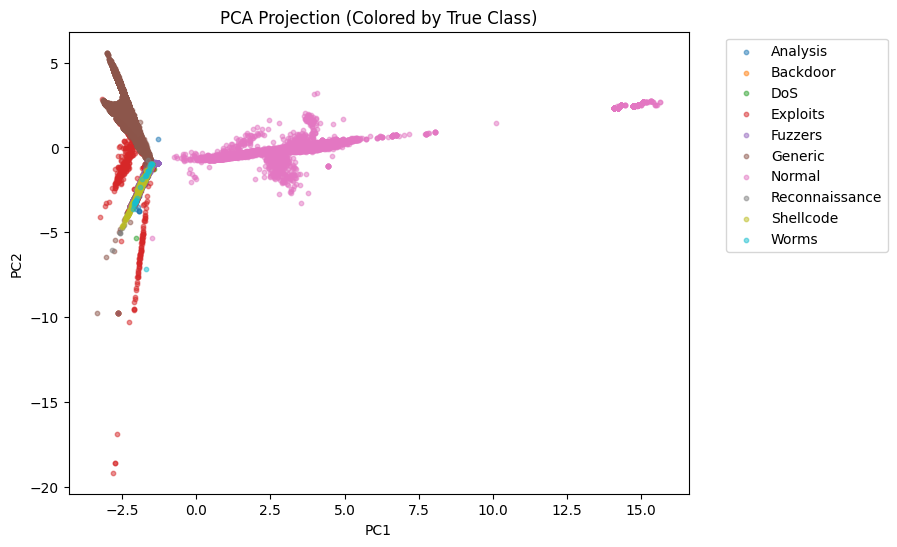

In [47]:
# Visualize KMeans Clustering Results

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)


# Assume kmeans has been fitted to learned_features and labels are in kmeans.labels_
# Reduce features to 2D for visualization

pca = PCA(n_components=2)

features_2d = pca.fit_transform(test_features_scaled)

label_mapping = dict(enumerate(df_og['attack_cat'].astype('category').cat.categories))


plt.figure(figsize=(8,6))

for label in np.unique(y_test):
    idx = y_test == label
    plt.scatter(
        features_2d[idx, 0],
        features_2d[idx, 1],
        label=label_mapping[label],
        alpha=0.5,
        s=10
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("PCA Projection (Colored by True Class)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## t-SNE Visualization

In [39]:
%pip install TSNE

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/547.6 kB ? eta -:--:--
     -------------------------------------- 547.6/547.6 kB 3.7 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> [63 lines of output]
      Ignoring numpy: markers 'python_version < "3.7"' don't match your environment
           ---------------------------------------- 0.0/5.1 MB ? eta -:--:--
           ---------------- ----------------------- 2.1/5.1 MB 14.7 MB/s eta 0:00:01
           ---------------------------------------  5.0/5.1 MB 14.4 MB/s eta 0:00:01
           ---------------------------------------- 5.1/5.1 MB 12.3 MB/s eta 0:00:00
        Installing build dependencies: started
        Installing build dependencies: finished with status 'done'
        Getting requirements to build wheel: started
        Getting requirements to build wheel: finished with status 'done'
        Preparing metadata (pyproject.toml): started
        Preparing metadata (pyproject.toml): finished with status 'error'
        error: subprocess-exited-with-error
      
      

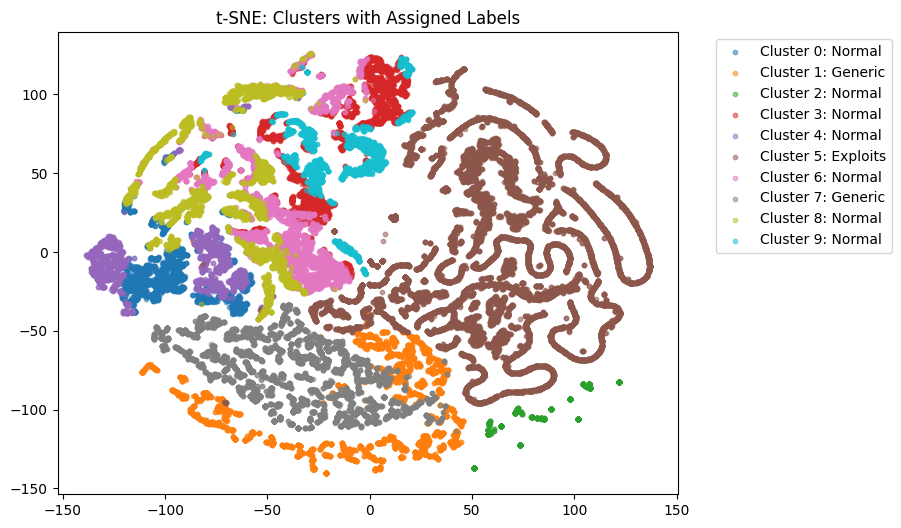

In [49]:
from sklearn.manifold import TSNE

cluster_names = {
    c: label_mapping[label]
    for c, label in cluster_to_label.items()
}

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
features_2d = tsne.fit_transform(test_features_scaled)

plt.figure(figsize=(8,6))

for cluster in np.unique(test_clusters):
    idx = test_clusters == cluster
    plt.scatter(
        features_2d[idx, 0],
        features_2d[idx, 1],
        label=f"Cluster {cluster}: {cluster_names.get(cluster, 'Unknown')}",
        alpha=0.5,
        s=10
    )

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title("t-SNE: Clusters with Assigned Labels")
plt.show()

## Discussion of Results

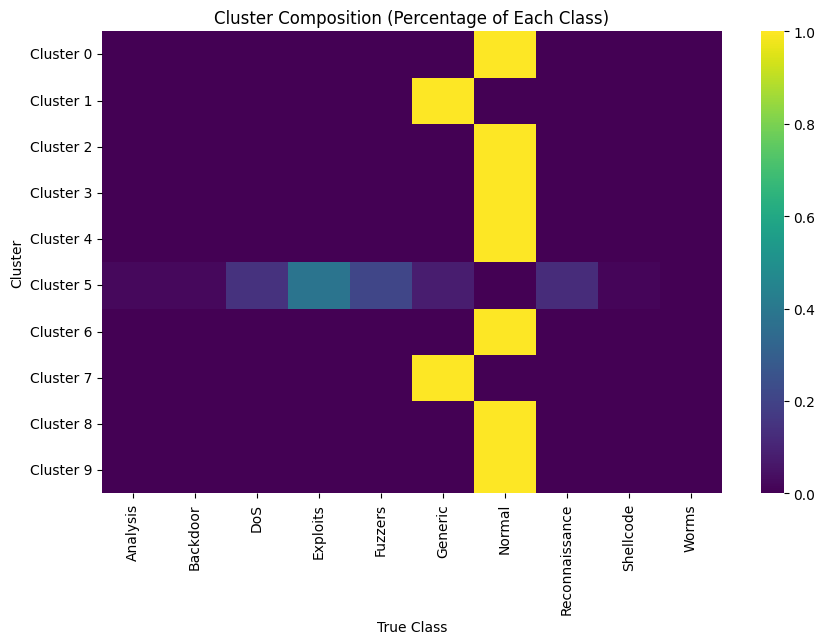

In [50]:
import seaborn as sns

ct = pd.crosstab(test_clusters, y_test, normalize='index')
plt.figure(figsize=(10,6))

sns.heatmap(
    ct,
    cmap="viridis",
    xticklabels=[label_mapping[i] for i in ct.columns],
    yticklabels=[f"Cluster {i}" for i in ct.index]
)

plt.title("Cluster Composition (Percentage of Each Class)")
plt.xlabel("True Class")
plt.ylabel("Cluster")
plt.show()

In [43]:
%pip install seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


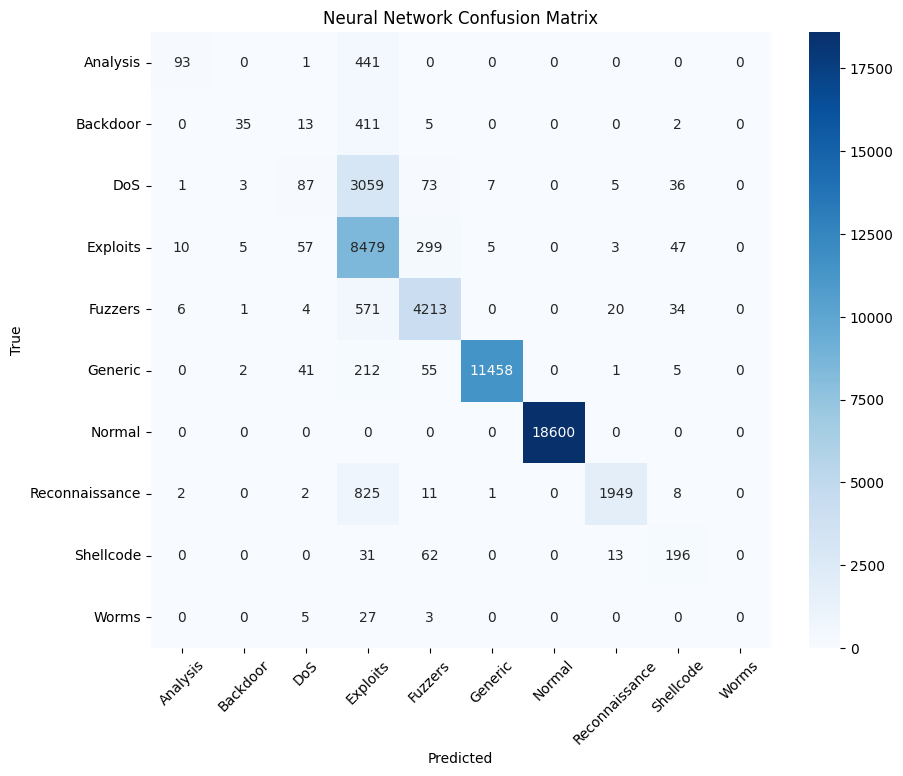

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_mapping.values(),
    yticklabels=label_mapping.values()
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Neural Network Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

### Successes

We can clearly see:
- A left, vertical band blue cluster. 
- A diagonal spread from blue -> yellow -> purple -> green. 

This means that our neural network successfully learned a structured feature space. 

*interestingly* the neural network learned a continuous behavioral gradient. This implies that instead of our categories being strict and rigid, we might have more of a specturm of activity (normal-slightly, abnormal, attack-like, attack).

The tall column on the left side of the graph indicates that this cluster is very tight in PCA1 and very wide in PCA2. This means that the network has likely identified a distinct type of behavior that the model can strongly separate. i.e; very consistent normal traffic or a specfic type of attack

### Limitations

There is still overalp in our clusters, so our separation is not perfect. This is an **unattainable** goal though, because some attacks resemble normal traffic and some behaviors are inherently ambiguous.

Furthermore, we use k-means. This is slightly problematic since our data isn't necessarily taking the shape of spherical clusters (point of k-means) but rather is elongated / diagonal. 